# HeritageNet — Results Dashboard

A single visual view of the trained model: **training curves**, **confusion matrix**,
and every **misclassified test image** shown inline.

This notebook *reuses* the project's modules (datamodule, factory) — it does not
reimplement anything, so what you see here matches your real pipeline.

> Initial model with backbone freeze

In [1]:
import os
# if we're inside notebooks/, step up to the repo root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("working dir:", os.getcwd())

working dir: d:\pratik\HeritageNet\HeritageNet


In [2]:
# --- setup ---
import json
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

from heritagenet.data.datamodule import HeritageDataModule
from heritagenet.models.factory import build_model
from heritagenet.utils.device import get_device

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

CKPT  = 'checkpoints/best.pt'
MODEL = 'mobilenet_v3_small'
device = get_device()
print('device:', device)

device: cuda


## Load the trained model and the test data

In [3]:
dm = HeritageDataModule(root='data', batch_size=32).setup()
classes = dm.classes
print(f'{dm.num_classes} classes, {len(dm.test_dataset)} test images')

model = build_model(MODEL, num_classes=dm.num_classes,
                    pretrained=False, freeze_backbone=False)
ckpt = torch.load(CKPT, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.to(device).eval()
print('loaded checkpoint from epoch', ckpt.get('epoch'),
      '| val_acc', ckpt.get('val_acc'))

26 classes, 179 test images
loaded checkpoint from epoch 8 | val_acc 0.7862068965517242


## 1 · Training curves

Loss and accuracy per epoch. Watch the gap between **train** and **val** — a widening
gap is overfitting. The dashed line marks the best epoch (where the checkpoint was saved).


loaded history from outputs\history.json


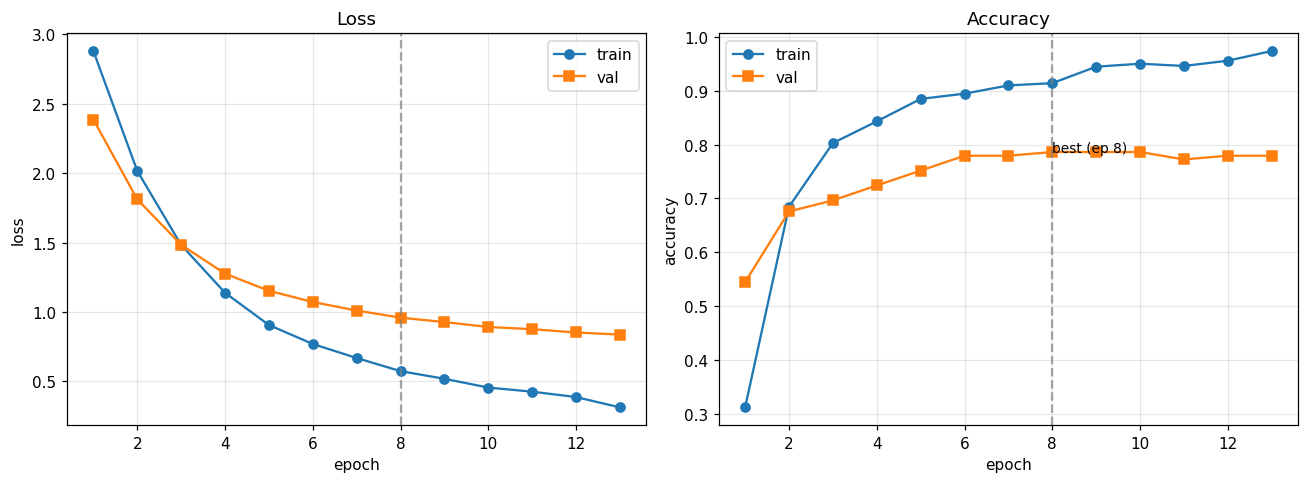

In [4]:
# Prefer a saved history.json; fall back to the first-run values.
hist_path = Path('outputs/history.json')
if hist_path.exists():
    H = json.loads(hist_path.read_text())
    print('loaded history from', hist_path)
else:
    # values recorded from the first training run
    H = {
      'train_loss':[2.351,1.777,1.393,1.103,0.877,0.736,0.652,0.556,0.484,0.445,
                    0.372,0.373,0.317,0.286,0.276,0.257,0.254,0.222,0.194],
      'train_acc' :[0.272,0.719,0.827,0.887,0.928,0.925,0.934,0.955,0.955,0.967,
                    0.982,0.979,0.985,0.976,0.973,0.988,0.964,0.994,0.991],
      'val_loss'  :[2.013,1.604,1.316,1.109,0.964,0.851,0.755,0.682,0.624,0.572,
                    0.532,0.504,0.477,0.455,0.429,0.407,0.388,0.370,0.358],
      'val_acc'   :[0.462,0.646,0.677,0.692,0.769,0.800,0.831,0.831,0.862,0.862,
                    0.877,0.908,0.908,0.923,0.923,0.923,0.923,0.923,0.923],
      'best_epoch':14,
    }
    print('using embedded first-run history (run updated train.py to save history.json)')

ep = range(1, len(H['train_loss']) + 1)
best = H.get('best_epoch')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
a1.plot(ep, H['train_loss'], 'o-', label='train'); a1.plot(ep, H['val_loss'], 's-', label='val')
a1.set_title('Loss'); a1.set_xlabel('epoch'); a1.set_ylabel('loss'); a1.legend(); a1.grid(alpha=.3)
a2.plot(ep, H['train_acc'], 'o-', label='train'); a2.plot(ep, H['val_acc'], 's-', label='val')
a2.set_title('Accuracy'); a2.set_xlabel('epoch'); a2.set_ylabel('accuracy'); a2.legend(); a2.grid(alpha=.3)
if best:
    for a in (a1, a2): a.axvline(best, ls='--', c='gray', alpha=.7)
    a2.annotate(f'best (ep {best})', xy=(best, max(H['val_acc'])), fontsize=9)
plt.tight_layout(); plt.show()

## 2 · Test-set metrics + confusion matrix

In [5]:
# predict on the test set (shuffle OFF so order matches file paths later)
loader = DataLoader(dm.test_dataset, batch_size=32, shuffle=False, num_workers=0)
y_true, y_pred = [], []
with torch.no_grad():
    for imgs, lbls in loader:
        p = model(imgs.to(device)).argmax(1).cpu()
        y_pred.extend(p.tolist()); y_true.extend(lbls.tolist())
y_true, y_pred = np.array(y_true), np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
mf1 = f1_score(y_true, y_pred, average='macro')
print(f'test accuracy: {acc:.3f}   macro-F1: {mf1:.3f}\n')
print(classification_report(y_true, y_pred, target_names=classes, digits=3, zero_division=0))

test accuracy: 0.799   macro-F1: 0.784

                                       precision    recall  f1-score   support

                  Ashok_stupa_Chaitya      0.889     1.000     0.941         8
                     Badrinath_Temple      0.800     0.800     0.800         5
                     Balkumari_Temple      0.714     1.000     0.833         5
                      Bhagwati_Temple      0.800     0.800     0.800         5
            Bhairahawa_Hanuman_Temple      1.000     1.000     1.000         5
            Bijayanagar_Gadesh_Mandir      1.000     0.600     0.750         5
                        Chamundra_Mai      0.800     0.571     0.667         7
                  Ganesh_Mandir_Patan      0.857     1.000     0.923         6
                           Heritage_1      1.000     0.800     0.889         5
                           Heritage_2      1.000     0.600     0.750        10
                           Heritage_3      0.750     0.500     0.600         6
Hiranya_Var

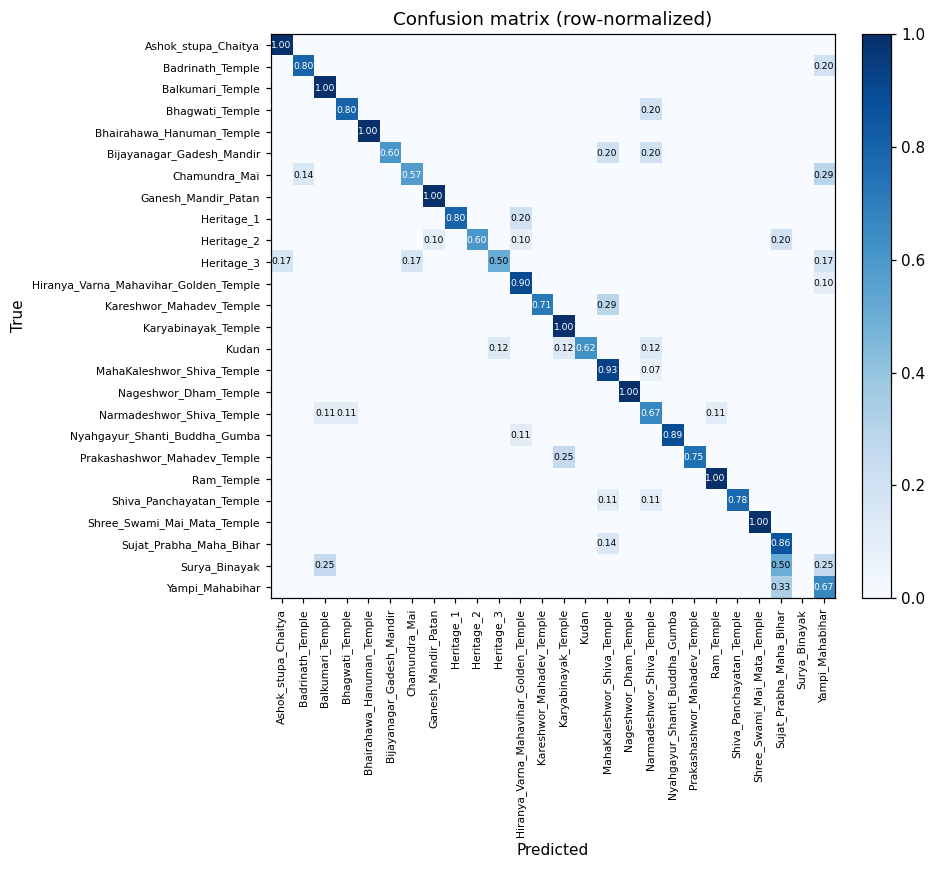

In [6]:
cm = confusion_matrix(y_true, y_pred, labels=range(dm.num_classes))
cmn = np.nan_to_num(cm / cm.sum(axis=1, keepdims=True))

n = dm.num_classes
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(classes, rotation=90, fontsize=7)
ax.set_yticklabels(classes, fontsize=7)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion matrix (row-normalized)')
for i in range(n):
    for j in range(n):
        if cmn[i, j] > 0:
            ax.text(j, i, f'{cmn[i,j]:.2f}', ha='center', va='center',
                    fontsize=6, color='white' if cmn[i,j] > .5 else 'black')
fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

## 3 · Every misclassified test image

The actual photos the model got wrong, shown with **TRUE** (real site) and **PRED**
(model's guess). Look across them for a shared pattern — similar backgrounds, similar
shooting distance, or genuinely similar architecture.

36 misclassified out of 179


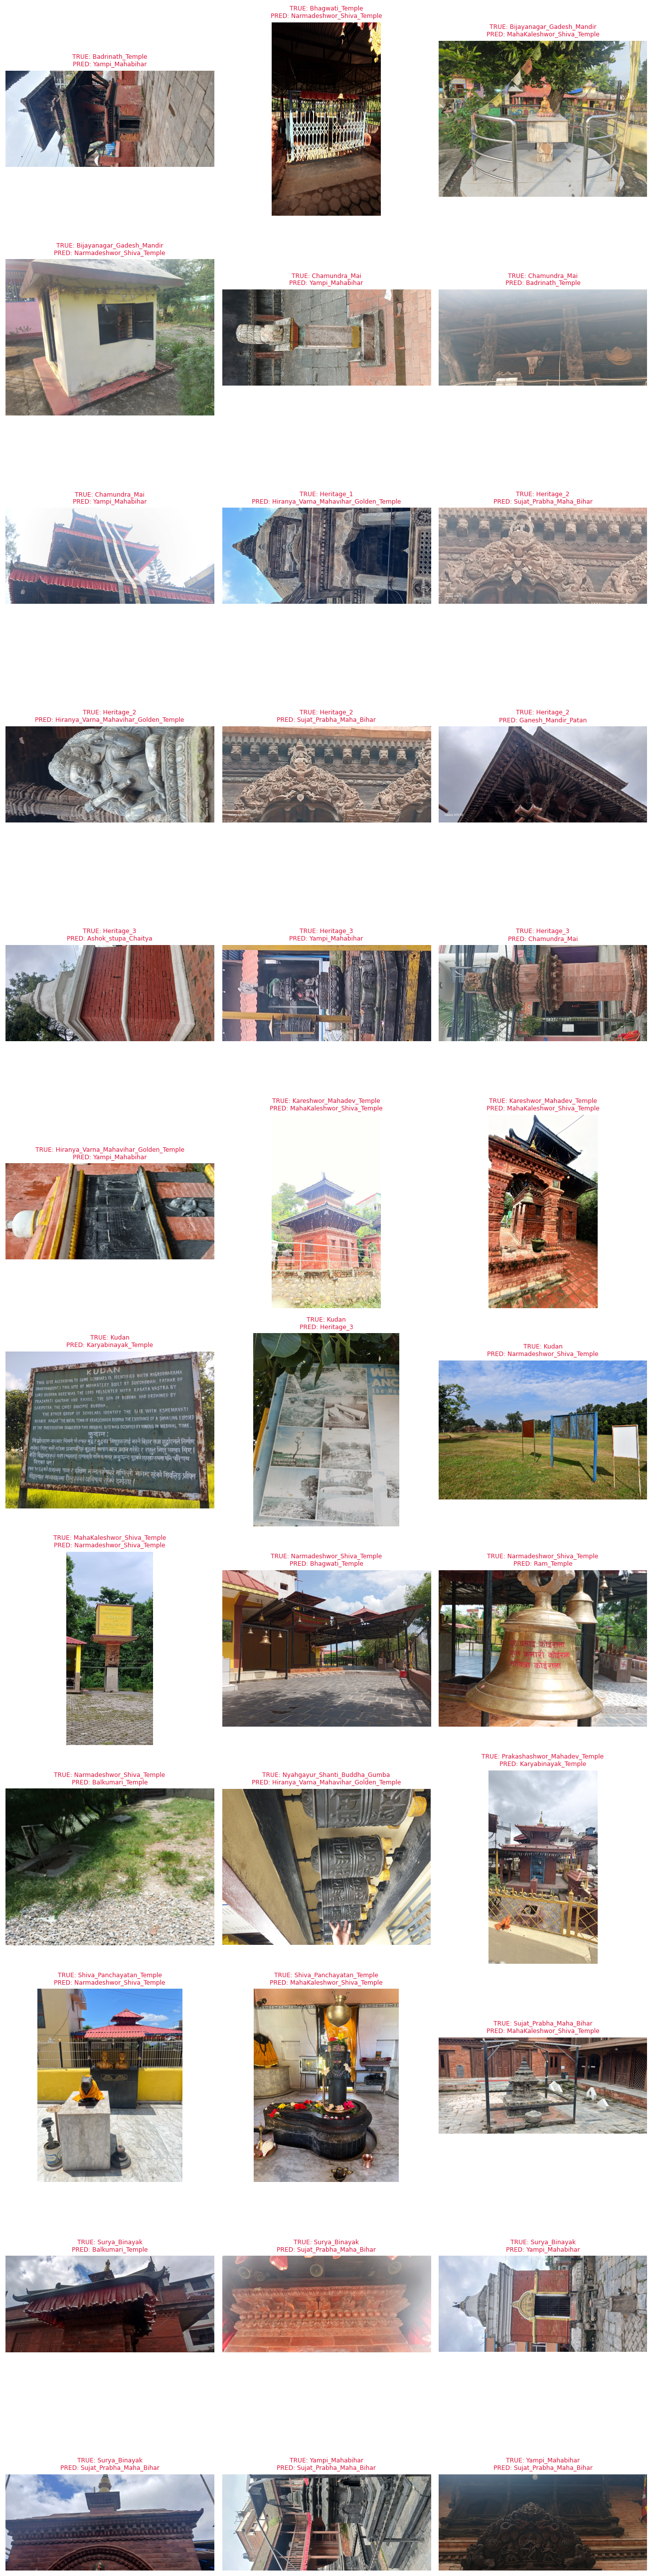

In [7]:
samples = dm.test_dataset.samples  # ordered (path, true_label), matches y_pred
wrong = [(Path(p), t, pr) for (p, t), pr in zip(samples, y_pred) if t != pr]
print(f'{len(wrong)} misclassified out of {len(samples)}')

if wrong:
    ncols = 3
    nrows = (len(wrong) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
    axes = np.array(axes).reshape(-1)
    for ax in axes: ax.axis('off')
    for ax, (path, t, pr) in zip(axes, wrong):
        ax.imshow(Image.open(path).convert('RGB'))
        ax.set_title(f'TRUE: {classes[t]}\nPRED: {classes[pr]}',
                     fontsize=8, color='crimson')
    plt.tight_layout(); plt.show()
else:
    print('No mistakes on the test set!')